In [1]:
!pip install opencv-python


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


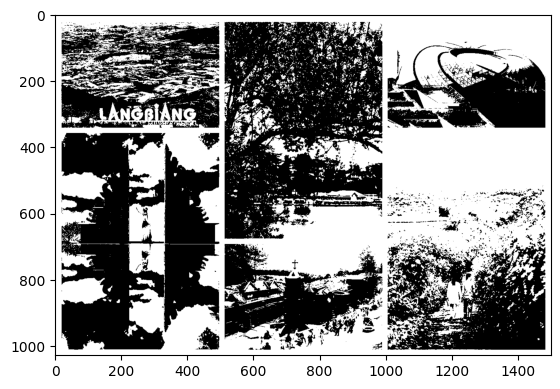

In [5]:
# 2.1.1 Phương pháp otsu
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters.thresholding import threshold_otsu

data = Image.open('exercise/dalat.jpg').convert('L')

a = np.asarray(data)

# performing Otsu's thresholding
thres = threshold_otsu(a)

# pixels with intensity greater than threshold are kept
b = a > thres

b = Image.fromarray(b)

plt.imshow(b)
plt.show()

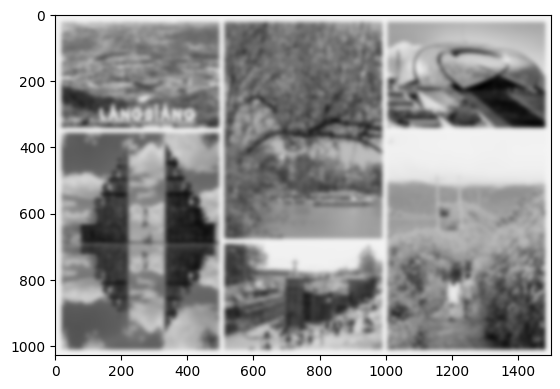

In [6]:
#2.1.2 Phương pháp Adaptive Thresholding
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import matplotlib.pylab as plt
from skimage.filters import threshold_local

data = Image.open('exercise/dalat.jpg').convert('L')

a = np.asarray(data)

# performing local thresholding
b = threshold_local(a, 39, offset=10)

b = Image.fromarray(b)

plt.imshow(b)
plt.show()

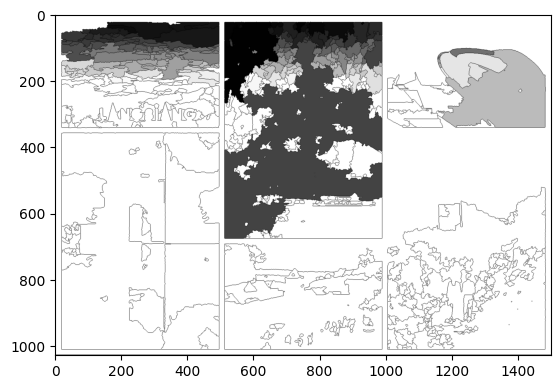

In [16]:
#2.2 Phân vùng theo region
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import scipy.ndimage as label # This line seems redundant, label is imported again later from scipy.ndimage
import matplotlib.pylab as plt
from skimage.filters import threshold_local

# opening the image and converting it to grayscale
data = cv2.imread('exercise/dalat.jpg')
# converting image from color to grayscale
a = cv2.cvtColor(data, cv2.COLOR_BGR2GRAY)
# thresholding the image to obtain cell pixels
thresh, b1 = cv2.threshold(a, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
# since Otsu's method has over segmented the image
# erosion operation is performed
b2 = cv2.erode(b1, None, iterations = 2)
# distance transform is performed
dist_trans = cv2.distanceTransform(b2, 2, 3)
# thresholding the distance transform image to obtain
# pixels that are foreground
thresh, dt = cv2.threshold(dist_trans, 1, 255, cv2.THRESH_BINARY)
# performing labeling
labelled, ncc = nd.label(dt) # Using nd.label as per the original image, assuming 'label' was meant to be from scipy.ndimage
# labelled is converted to 32-bit integer
labelled = labelled.astype(np.int32)
# performing watershed
cv2.watershed(data, labelled)
b = Image.fromarray(labelled)

plt.imshow(b)
plt.show()


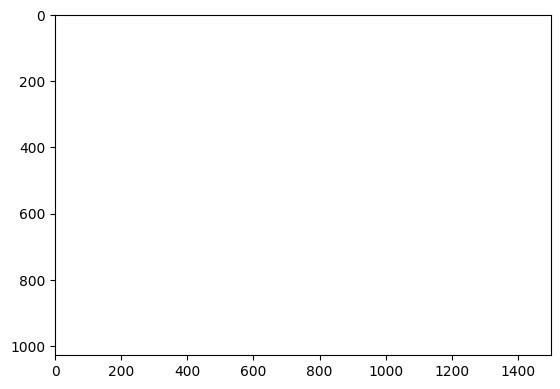

In [22]:
#2.3.1 Sử dụng binary_dilation
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
import scipy.ndimage as label
import matplotlib.pylab as plt
from skimage.filters import threshold_local

# opening the image and converting it to grayscale
data = Image.open('exercise/dalat.jpg').convert('L')
b = nd.binary_dilation(data, iterations=50)

c = Image.fromarray(b)
c.show()
plt.imshow(c)
plt.show()


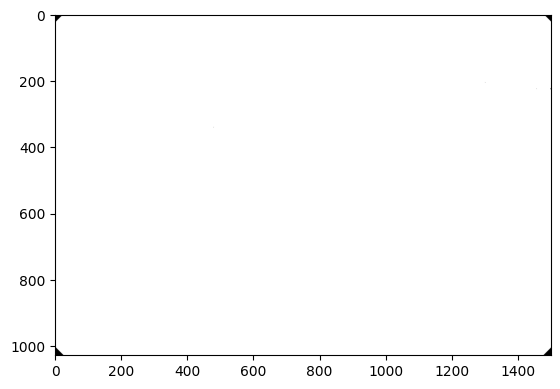

In [21]:
#2.3.2 Sử dụng binary_opening
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pylab as plt
from skimage.filters import threshold_local

# opening the image and converting it to grayscale
data = Image.open('exercise/dalat.jpg').convert('L')
# defining the structuring element
s = [[0, 1, 0], [1, 1, 1], [0, 1, 0]]
b = nd.binary_opening(data, structure=s, iterations=25)

c = Image.fromarray(b)
c.show()
plt.imshow(c)
plt.show()


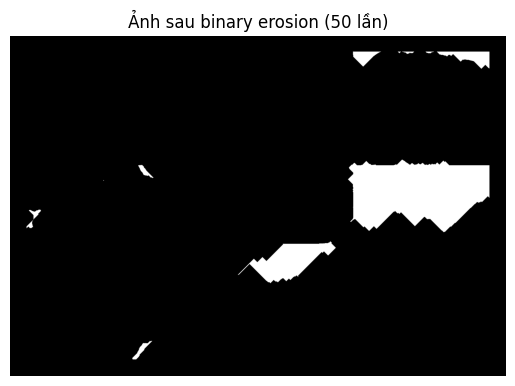

In [29]:
#2.3.3 Sử dụng binary_erosion
import cv2
from PIL import Image
import numpy as np
import scipy.ndimage as nd
import matplotlib.pyplot as plt

# Mở ảnh và chuyển sang grayscale (ảnh mức xám)
data = Image.open('exercise/dalat.jpg').convert('L')
gray = np.array(data)

# Chuyển sang ảnh nhị phân: pixel > 128 là True (foreground)
binary = gray > 128

# Định nghĩa structuring element hình chữ thập
structure = np.array([[0, 1, 0],
                      [1, 1, 1],
                      [0, 1, 0]])

# Áp dụng erosion 50 lần
eroded = nd.binary_erosion(binary, structure=structure, iterations=50)

# Chuyển về ảnh để hiển thị
eroded_img = Image.fromarray((eroded * 255).astype(np.uint8))

# Hiển thị ảnh kết quả
plt.imshow(eroded_img, cmap='gray')
plt.title("Ảnh sau binary erosion (50 lần)")
plt.axis('off')
plt.show()


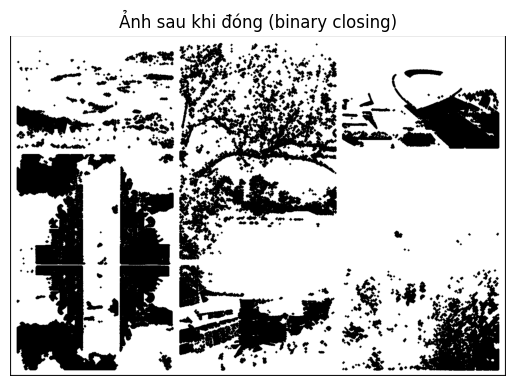

In [25]:
#2.3.4 Sử dụng binary_closing
import cv2
from PIL import Image
import numpy as np
import scipy.ndimage as nd
import matplotlib.pyplot as plt

# Đọc ảnh và chuyển sang ảnh xám
data = Image.open('exercise/dalat.jpg').convert('L')
gray = np.array(data)

# Chuyển ảnh xám thành nhị phân (ví dụ ngưỡng 128)
binary = gray > 128   # dạng boolean: True (1), False (0)

# Định nghĩa kernel hình chữ thập
structure = np.array([[0, 1, 0],
                      [1, 1, 1],
                      [0, 1, 0]])

# Áp dụng binary closing (đóng)
closed = nd.binary_closing(binary, structure=structure, iterations=3)

# Chuyển lại thành ảnh để hiển thị
closed_img = Image.fromarray((closed * 255).astype(np.uint8))

# Hiển thị kết quả
plt.imshow(closed_img, cmap='gray')
plt.title("Ảnh sau khi đóng (binary closing)")
plt.axis('off')
plt.show()
